In [36]:
# Imports, variables, function definitions. Must be run first, but does not need to be changed. 

# Import Relevant Modules
import math
import re
from datetime import datetime
import time
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import clear_output
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import json
import ipywidgets as widgets
from typing import Any, Dict, List, Optional, Tuple

# Define global variables and default settings

# Log file location on laptop: 'C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-Logs/*'
# Tera term log file location on laptop: 'C:/Users/Experiment/cbmark_logger/Tera Term logs/*'
# WebMonitor log file location on laptop : 'C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-WMLogs/*'

# ================= Default file paths for log files =================
teraTerm_log_path902b   = "C:/Users/Experiment/cbmark_logger/Tera Term logs/*"
webMonitor_path         = 'C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-WMLogs/*'
kepco_path              = "C:/Users/Experiment/Code/Kepco-Dashboard/logs"
# ============================================================

# File path storage, set to defaults above on first run 
file_paths = {
    "webMonitor file path" : webMonitor_path.replace('\\', '/'),
    "902b file path" : teraTerm_log_path902b.replace('\\', '/'),
    "Kepco log file path" : kepco_path.replace('\\', '/')
}

# Integer type settings
int_settings = {
    # Positive number of previous webMonitor files to read at first initialization
    # Select 0 to use only most recent WM file
    "Number of previous WM Files to read" : 0,

    # Keep last N minutes of WebMonitor data in memory (set to 0 to keep everything).
    "WM time window size (minutes)" : 0,

    # Figure size parameters
    "fig width" : 18,
    "fig height" : 10,
    "fig y ticks" : 5,

    # Column settings
    "number of columns" : 2,
}

# This and legacy_graph_settings store the names for each subplot and line in the subplot
# Modify "enabled" to turn on or off each subplot
graph_settings = {
    'PMON temperatures': {
        "lines" : ["pmon1", "pmon2", "pmon3", "pmon4", "pmon5", "pmon6"],
        "unit": "°C",
        "enabled": True,
        "hasData": False
    },
    'CCS temperatures': {
        "lines": ["ccs_A_temp", "ccs_B_temp", "ccs_C_temp"],
        "unit": "°C",
        "enabled": True,
        "hasData": False
    },
    'Chamber pressure': {
        "lines": ["vtrx_pressure"],
        "unit": "mbar",
        "enabled": True,
        "hasData": False
    },
    'CCS voltages': {
        "lines": ["ccs_A_voltage", "ccs_B_voltage", "ccs_C_voltage"],
        "unit": "V",
        "enabled": True,
        "hasData": False
    },
    'CCS currents': {
        "lines": ["ccs_A_current", "ccs_B_current", "ccs_C_current"],
        "unit": "A",
        "enabled": True,
        "hasData": False
    },
    '20kV PSU voltage':   {
        "lines": ['hvActualVolt20kv', 'hvSetVolt20kv'],
        "unit": "V",
        "enabled": True,
        "hasData": False
    },
    '20kV PSU current':   {
        "lines": ['hvCurrent20kv'],
        "unit": "mA",
        "enabled": True,
        "hasData": False
    },
    '3kV PSU voltage':    {
        "lines": ['hvActualVolt3kv', 'hvSetVolt3kv'],
        "unit": "V",
        "enabled": True,
        "hasData": False
    },
    '3kV PSU current':    {
        "lines": ['hvCurrent3kv'],
        "unit": "mA",
        "enabled": True,
        "hasData": False
    },
    '+1kV PSU voltage': {
        "lines": ['hvActualVoltPos1kv', 'hvSetVoltPos1kv'],
        "unit": "V",
        "enabled": True,
        "hasData": False
    },
    '+1kV PSU current': {
        "lines": ['hvCurrentPos1kv'],
        "unit": "mA",
        "enabled": False,
        "hasData": False
    },
    '-1kV PSU voltage': {
        "lines": ['hvActualVoltNeg1kv', 'hvSetVoltNeg1kv'],
        "unit": "V",
        "enabled": True,
        "hasData": False
    },
    '-1kV PSU current': {
        "lines": ['hvCurrentNeg1kv'],
        "unit": "mA",
        "enabled": False,
        "hasData": False
    },
    'Both 1kV currents': {
        "lines": ['hvCurrentPos1kv', 'hvCurrentNeg1kv'],
        "unit": "mA",
        "enabled": True,
        "hasData": False
    }
}

legacy_graph_settings = {
    '902b pressure': {
        "lines": ["Pressure (mbar)"],
        "unit": "mbar",
        "enabled": False,
        "hasData": False
    },

    'Kepco voltage': {
                "lines": ["Voltage"],
                "unit": "V",
                "enabled": True,
                "hasData": False
            },

    'Kepco current': {
            "lines": ["Current"],
            "unit": "A",
            "enabled": True,
            "hasData": False
        }
}

# Global variable for storing legacy graph data
legacy_graph_dataframes = {
            '902b pressure': pd.DataFrame(columns=["Time", "Pressure (mbar)"]),
            'Kepco voltage': pd.DataFrame(columns=["Time",  "Voltage"]),
            'Kepco current': pd.DataFrame(columns=["Time",  "Current"])
        }

# Internal state for incremental reads:
# - path: last filename read (used to detect log rotation / filename change)
# - pos: byte offset within the file
# - remainder: trailing partial line (bytes) when the writer hasn't flushed a newline yet
_webmon_tail_state = {"path": None, "pos": 0, "remainder": b""}
_webmon_cache_df = pd.DataFrame()

# Spot to store control widgets
controlWidgets = []

# ==========================================================
# Define functions
# ==========================================================

# This function reads only newly appended lines from a file based on the last read (stored in state)
# It returns a list of decoded lines (strings) that have been appended since the last call
def _read_appended_json_lines(path: str, state: Dict[str, Any]) -> List[str]:
    """Read and decode newly appended lines from a JSON log file.

    Args:
        path: Path to the log file.
        state: Mutable state containing the last read position and pending remainder.

    Returns:
        List of complete decoded lines appended since the last call.
    """
    # Detect filename change (log rotation) and restart reading from the beginning
    # of the new file. We intentionally do NOT clear _webmon_cache_df here, so
    # plots can show continuity across files.
    if state["path"] != path:
        state["path"] = path
        state["pos"] = 0
        state["remainder"] = b""

    try:
        size = os.path.getsize(path)
    except OSError:
        return []

    # If the file shrank, it was replaced/truncated: reset to the start.
    if size < state["pos"]:
        state["pos"] = 0
        state["remainder"] = b""

    # Read only the bytes appended since the last call.
    with open(path, "rb") as f:
        f.seek(state["pos"])
        chunk = f.read()
        state["pos"] = f.tell()

    if not chunk:
        return []

    # Prepend any partial line we carried over from last time, then split by newline.
    data = state["remainder"] + chunk
    parts = data.split(b"\n")

    # If the writer didn't end with a newline, keep the last fragment for next time.
    if data.endswith(b"\n"):
        state["remainder"] = b""
        complete = parts[:-1]
    else:
        state["remainder"] = parts[-1]
        complete = parts[:-1]

    lines = []
    for bline in complete:
        bline = bline.strip()
        if not bline:
            continue
        try:
            lines.append(bline.decode("utf-8"))
        except UnicodeDecodeError:
            lines.append(bline.decode("utf-8", errors="replace"))
    return lines


# This function extracts data from the web monitor log file, which is in JSON format
# It outputs a pandas DataFrame with a timestamp index and columns for each sensor reading
def getDataFromWebMonitorFile(filename: Optional[str]) -> pd.DataFrame:
    """Read newly appended WebMonitor JSON log records into a pandas DataFrame.

    Args:
        filename: Path to the WebMonitor JSON log file. If None, returns the current cache.

    Returns:
        A pandas DataFrame indexed by timestamp containing the parsed WebMonitor fields.
    """
    # Incremental (tail) parser.
    # Returns a cached DataFrame that grows as the file grows (that is then trimmed to a
    # rolling time window)
    global _webmon_tail_state
    global _webmon_cache_df

    if not filename:
        return _webmon_cache_df

    # Pull only newly appended, complete JSON lines.
    new_lines = _read_appended_json_lines(filename, _webmon_tail_state)
    if not new_lines:
        return _webmon_cache_df

    # Parse JSON objects and flatten them into row dictionaries.
    records = []
    for line in new_lines:
        try:
            data = json.loads(line)
        except json.JSONDecodeError:
            continue
        
        # Default values in case keys are missing
        timestamp = None
        status = None 
        pressure = None
        temps = {"1": None, "2": None, "3": None, "4": None, "5": None, "6": None}
        cathA = {"heater_current": None, "heater_voltage": None, "clamp_temperature": None}
        cathB = {"heater_current": None, "heater_voltage": None, "clamp_temperature": None}
        cathC = {"heater_current": None, "heater_voltage": None, "clamp_temperature": None}
        pos1kv = {"meas_v": None, "set_v": None, "meas_i": None}
        neg1kv = {"meas_v": None, "set_v": None, "meas_i": None}
        pos20kv = {"meas_v": None, "set_v": None, "meas_i": None}
        pos3kv = {"meas_v": None, "set_v": None, "meas_i": None}

        if "timestamp" in data :
            timestamp = data["timestamp"]

            if("status" in data) :
                status = data["status"]
                pressure = status["pressure"]
                temps = status["temperatures"]
                
                if "cathode" in status:
                    cathA = status["cathode"]["A"]
                    cathB = status["cathode"]["B"]
                    cathC = status["cathode"]["C"]

                if "beam_energy" in status:
                    beam_energy = status["beam_energy"]
                    if(beam_energy is not None) :
                        pos1kv = beam_energy["pos1kv"]
                        neg1kv = beam_energy["neg1kv"]
                        pos20kv = beam_energy["pos20kv"]
                        pos3kv = beam_energy["pos3kv"]
            

        record = {
            "timestamp": timestamp,
            "vtrx_pressure": pressure,
            
            "pmon1": temps["1"],
            "pmon2": temps["2"],
            "pmon3": temps["3"],
            "pmon4": temps["4"],
            "pmon5": temps["5"],
            "pmon6": temps["6"],

            "ccs_A_current": cathA["heater_current"],
            "ccs_A_voltage": cathA["heater_voltage"],
            "ccs_A_temp":    cathA["clamp_temperature"],

            "ccs_B_current": cathB["heater_current"],
            "ccs_B_voltage": cathB["heater_voltage"],
            "ccs_B_temp":    cathB["clamp_temperature"],

            "ccs_C_current": cathC["heater_current"],
            "ccs_C_voltage": cathC["heater_voltage"],
            "ccs_C_temp":    cathC["clamp_temperature"],

            'hvActualVolt20kv': pos20kv["meas_v"],
            'hvSetVolt20kv': pos20kv["set_v"],
            'hvCurrent20kv': pos20kv["meas_i"],

            'hvActualVolt3kv': pos3kv["meas_v"],
            'hvSetVolt3kv': pos3kv["set_v"],
            'hvCurrent3kv': pos3kv["meas_i"],

            'hvActualVoltPos1kv': pos1kv["meas_v"],
            'hvSetVoltPos1kv': pos1kv["set_v"],
            'hvCurrentPos1kv': pos1kv["meas_i"],

            'hvActualVoltNeg1kv': neg1kv["meas_v"],
            'hvSetVoltNeg1kv': neg1kv["set_v"],
            'hvCurrentNeg1kv': neg1kv["meas_i"],
        }
        records.append(record)

    if not records:
        return _webmon_cache_df

    # Convert to DataFrame and normalize types used by plotting.
    new_df = pd.DataFrame(records)
    if new_df.empty:
        return _webmon_cache_df

    new_df["timestamp"] = pd.to_datetime(new_df["timestamp"], errors="coerce")
    new_df = new_df.dropna(subset=["timestamp"])

    for subplot in graph_settings :
        for col in graph_settings[subplot]["lines"] :
            if col in new_df.columns:
                new_df[col] = pd.to_numeric(new_df[col], errors="coerce")

    new_df = new_df.set_index("timestamp")

    # Append new rows into the cache.
    if _webmon_cache_df is None or _webmon_cache_df.empty:
        _webmon_cache_df = new_df
    else:
        _webmon_cache_df = pd.concat([_webmon_cache_df, new_df])

    # Keep index ordered
    _webmon_cache_df = _webmon_cache_df.sort_index()

    # Enforce a rolling time window so memory/plotting time stays bounded.
    if int_settings['WM time window size (minutes)'] != 0 and not _webmon_cache_df.empty:
        cutoff = _webmon_cache_df.index.max() - pd.Timedelta(minutes=int_settings['WM time window size (minutes)'])
        _webmon_cache_df = _webmon_cache_df[_webmon_cache_df.index >= cutoff]

    return _webmon_cache_df


# This function extracts pressure data from the 902b log file, which is in a custom text format
# It outputs a dataframe with columns for timestamp and pressure readings

# This is a remnant of IC's first revision of the code, which was based on code from ND
# This function uses regex, so it is a bit slow and should be called on only if needed (i.e. if the 902b pressure graph is enabled)
# If it stops parsing correctly, print the lines being read and use regex101.com to debug the regex string
def get902bPressureData(filename: str) -> pd.DataFrame:
    """Parse pressure readings from a 902b legacy log file.

    Args:
        filename: Path to the legacy 902b log file.

    Returns:
        A DataFrame with columns 'Time' and 'Pressure (mbar)'.
    """

    # Create an empty list to store the extracted data before converting it to a DataFrame
    data = []                          
    # Regex pattern to parse lines in the 902b log file for timestamps and pressure readings
    regex_pattern = re.compile(r'\[(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})\] @\d{3}ACK(\d*\.\d*);FF', re.I)
    # Columns for the DataFrame
    columns=["Time", "Pressure (mbar)"]
    
    with open(filename, "r") as f:
        for line in f:
            p = regex_pattern.search(line)
            if p:
                time_str = p.group(1)
                pressure = p.group(2)

                data.append((time_str, pressure))
                
    # Convert the list of tuples into a DataFrame and convert data types
    df = pd.DataFrame(data, columns=columns)
    if(not df.empty) :
        df['Time'] = pd.to_datetime(df['Time'].astype(str), format = "mixed")

        for col in range(1, len(columns)) :
            df[columns[col]] = pd.to_numeric(df[columns[col]])

    # Enforce a rolling time window so memory/plotting time stays bounded.
    if int_settings['WM time window size (minutes)'] != 0 and not df.empty:
        cutoff = df['Time'].max() - pd.Timedelta(minutes=int_settings['WM time window size (minutes)'])
        df = df[df['Time'] >= cutoff]

    return df

# This is a remnant of IC's first revision of the code, which was based on code from ND
# This function uses regex, so it is a bit slow and should be called on only if needed (i.e. if the Kepco graphs are enabled)
# If it stops parsing correctly, print the lines being read and use regex101.com to debug the regex string
def getKepcoData(filename: str) -> pd.DataFrame:
    """Parse pressure readings from a Kepco legacy log file.

    Args:
        filename: Path to the legacy Kepco log file.

    Returns:
        A DataFrame with columns 'Time', 'Voltage', and 'Current'.
    """

    # Create an empty list to store the extracted data before converting it to a DataFrame
    data = []                          
    # Regex pattern to parse lines in the Kepco log file for timestamps and pressure readings
    regex_pattern = re.compile(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),\d*.\d*,(\d*.\d*),(\d*.\d*),ON,', re.I)
    # Columns for the DataFrame
    columns=["Time", "Voltage", "Current"]
    
    with open(filename, "r") as f:
        for line in f:
            p = regex_pattern.search(line)
            if p:
                time_str = p.group(1)
                voltage = p.group(2)
                current = p.group(3)

                data.append((time_str,  voltage,  current))
                
    # Convert the list of tuples into a DataFrame and convert data types
    df = pd.DataFrame(data, columns=columns)
    if(not df.empty) :
        df['Time'] = pd.to_datetime(df['Time'].astype(str), format = "mixed")

        for col in range(1, len(columns)) :
            df[columns[col]] = pd.to_numeric(df[columns[col]])

    # Enforce a rolling time window so memory/plotting time stays bounded.
    if int_settings['WM time window size (minutes)'] != 0 and not df.empty:
        cutoff = df['Time'].max() - pd.Timedelta(minutes=int_settings['WM time window size (minutes)'])
        df = df[df['Time'] >= cutoff]

    return df

# This function gets all data from the other relevant functions
# It returns a dictionary of dataframes for legacy graph data and a dataframe for webMonitor data
def getAllData() -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """Collect current WebMonitor and legacy graph data.

    Returns:
        A tuple of (webMonitor_df, legacy_graph_dataframes).
    """

    def _most_recent_file(pattern: str) -> Optional[str]:
        files = glob.glob(pattern)
        if not files:
            print(f"""
                ------------------------------------
                No files found for path: {pattern}\n
                Please check the file path!
                ------------------------------------
                \n\n\n""")
            return None
        return max(files, key=os.path.getmtime)

    # WebMonitor is always used
    webMonitorFile = _most_recent_file(file_paths['webMonitor file path'])
    webMonitor_df = getDataFromWebMonitorFile(webMonitorFile)

    # Only parse legacy log files if any legacy graphs are enabled
    if any(cfg.get("enabled") for cfg in legacy_graph_settings.values()):
        teraTerm_log_path902b = _most_recent_file(file_paths['902b file path']) 
        pressure_df = get902bPressureData(teraTerm_log_path902b) if teraTerm_log_path902b else pd.DataFrame(columns=["Time", "Pressure (mbar)"])
        legacy_graph_dataframes['902b pressure'] = pressure_df
        kepco_path  = _most_recent_file(file_paths['Kepco log file path'])
        kepco_df = getKepcoData(kepco_path)  if kepco_path else pd.DataFrame(columns=["Time",  "Voltage", "Current"])
        legacy_graph_dataframes["Kepco voltage"]["Time"] = kepco_df["Time"]
        legacy_graph_dataframes["Kepco voltage"]["Voltage"] = kepco_df["Voltage"]
        legacy_graph_dataframes["Kepco current"]["Time"] = kepco_df["Time"]
        legacy_graph_dataframes["Kepco current"]["Current"] = kepco_df["Current"]

    return webMonitor_df, legacy_graph_dataframes


def getNumPlots(
    legacy_graph_dataframes: Dict[str, pd.DataFrame],
    webMonitor_df: pd.DataFrame,
) -> int:
    """Determine how many plot panels are needed based on available data.

    Args:
        legacy_graph_dataframes: Dictionary of legacy plot DataFrames.
        webMonitor_df: DataFrame with WebMonitor data.

    Returns:
        Number of non-empty plots to render.
    """
    # Count the number of non-empty data frames we have
    numPlots = 0

    # Used to only enable subplot if it has data
    keepSubplotEnabled = False 

    for subplot in graph_settings :
        keepSubplotEnabled = False 
 
        if(graph_settings[subplot]["enabled"]) :
            for line in graph_settings[subplot]["lines"] :
                if (line in webMonitor_df) and (not(webMonitor_df[line].empty)) :
                    numPlots += 1
                    keepSubplotEnabled = True
                    break # Only count 1 plot for each graph type, even if multiple columns are enabled

        graph_settings[subplot]["hasData"] = keepSubplotEnabled

    # Still using the legacy method for data that is not in the webmonitor file

    for subplot in legacy_graph_settings :
        keepSubplotEnabled = False

        if legacy_graph_settings[subplot]["enabled"] :
            for line in legacy_graph_settings[subplot]["lines"] :
                if(subplot in legacy_graph_dataframes) :
                    dataframe = legacy_graph_dataframes[subplot]
                    if (line in dataframe) and (not(dataframe[line].empty)) :
                        numPlots += 1
                        keepSubplotEnabled = True
                        break # Only count 1 plot for each graph type, even if multiple columns are enabled

        legacy_graph_settings[subplot]["hasData"] = keepSubplotEnabled
    return numPlots


# This function constructs and returns the graph object (fig and axs)
def getGraph(numPlots: int) -> Any:
    """Build a matplotlib axes grid for the configured number of plots.

    Args:
        numPlots: Number of subplots to create.

    Returns:
        The axes object or array returned by plt.subplots.
    """

    if numPlots < 2:
        print("Number of non-empty plots must be >= 2!")
        return
    
    numRows = math.ceil(numPlots / int_settings['number of columns'])

    # Set graph details, including figure aspect ratio and graph height ratios
    fig, axs = plt.subplots(numRows, int_settings['number of columns'], figsize=(int_settings['fig width'],
                            int_settings['fig height']),sharex=True, squeeze=False)

    return axs


# This function takes in data and graph settings and updates the graph with the relevant data, formatting, and legends
def updateGraph(
    legacy_graph_dataframes: Dict[str, pd.DataFrame],
    webMonitor_df: pd.DataFrame,
    numPlots: int,
    axs: Any,
) -> None:
    """Render webMonitor and legacy plots on the supplied axes.

    Args:
        legacy_graph_dataframes: Dictionary of legacy plot DataFrames.
        webMonitor_df: DataFrame with WebMonitor data.
        numPlots: Number of subplots expected.
        axs: Axes object or array returned by getGraph.
    """
    if numPlots < 2:
        print("Number of non-empty plots must be >= 2!")
        return
    
    numRows = math.ceil(numPlots / int_settings['number of columns'])
    numCols = int_settings['number of columns']

    curr_row = 0
    curr_col = 0

    # Plot all web monitor data
    for subplot in graph_settings :
        if(graph_settings[subplot]["hasData"] and graph_settings[subplot]["enabled"]) :
            for col in graph_settings[subplot]["lines"] :
                label = col + ' (' +  webMonitor_df[col].iloc[-1].astype(str) + graph_settings[subplot]["unit"] + ')'
                if(numCols == 1) :
                    axs[curr_row, 0].plot(webMonitor_df[col], label=label)
                    if(graph_settings[subplot]["unit"] == "mbar") :
                        axs[curr_row, 0].set_yscale('log')
                else :
                    axs[curr_row, curr_col].plot(webMonitor_df[col], label=label)
                    if(graph_settings[subplot]["unit"] == "mbar") :
                        axs[curr_row, curr_col].set_yscale('log')
        
            if(numCols == 1) :
                axs[curr_row, 0].set_ylabel(subplot)
                axs[curr_row, 0].legend(loc='upper left')
                axs[curr_row, 0].grid(True)
                axs[curr_row, 0].yaxis.set_major_locator(ticker.MaxNLocator(nbins=int_settings['fig y ticks']))
                curr_row += 1
            else :
                axs[curr_row, curr_col].set_ylabel(subplot)
                axs[curr_row, curr_col].legend(loc='upper left')
                axs[curr_row, curr_col].grid(True)
                axs[curr_row, curr_col].yaxis.set_major_locator(ticker.MaxNLocator(nbins=int_settings['fig y ticks']))
                if((curr_row == numRows - 1) and (curr_col < numCols - 1)) :
                    curr_col += 1
                    curr_row = 0
                else :
                    curr_row += 1
            

    # Plot all legacy data
    for entry in legacy_graph_settings :
        if(legacy_graph_settings[entry]["hasData"] and legacy_graph_settings[entry]["enabled"]) :
            for col in legacy_graph_settings[entry]["lines"] :
                dataframe = legacy_graph_dataframes[entry]
                label = col + ' (' +  dataframe[col].iloc[-1].astype(str) + legacy_graph_settings[entry]["unit"] + ')'
                
                if(numCols == 1) :
                    axs[curr_row, 0].plot(dataframe['Time'], dataframe[col], label=label)
                else :
                    axs[curr_row, curr_col].plot(dataframe['Time'], dataframe[col], label=label)
        
            if(numCols == 1) :
                axs[curr_row, 0].set_ylabel(entry)
                axs[curr_row, 0].legend(loc='upper left')
                axs[curr_row, 0].grid(True)
                axs[curr_row, 0].yaxis.set_major_locator(ticker.MaxNLocator(nbins=int_settings['fig y ticks']))
                curr_row += 1
            else :
                axs[curr_row, curr_col].set_ylabel(entry)
                axs[curr_row, curr_col].legend(loc='upper left')
                axs[curr_row, curr_col].grid(True)
                axs[curr_row, curr_col].yaxis.set_major_locator(ticker.MaxNLocator(nbins=int_settings['fig y ticks']))
                if((curr_row == numRows - 1) and (curr_col < numCols - 1)) :
                    curr_col += 1
                    curr_row = 0
                else :
                    curr_row += 1


    # Format x axis
    if(numCols == 1) :
        axs[numPlots-1, 0].xaxis.set_major_locator(ticker.MaxNLocator(nbins=(40)))
        axs[numPlots-1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        for label in axs[numPlots-1, 0].get_xticklabels():
            label.set_rotation(45)       # Rotate the label
            label.set_ha('right')        # Align the label to the right of the tick mark
        axs[numPlots-1, 0].set_xmargin(0)
    else :
        for col in range(numCols) :
            axs[numRows-1, col].xaxis.set_major_locator(ticker.MaxNLocator(nbins=int(40/numCols)))
            axs[numRows-1, col].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
            for label in axs[numRows-1, col].get_xticklabels():
                label.set_rotation(45)       # Rotate the label
                label.set_ha('right')        # Align the label to the right of the tick mark
            axs[numRows-1, col].set_xmargin(0)

    plt.tight_layout(h_pad=0, w_pad=1.13)
    plt.show()


# Read previous n webMonitor files (if available)
# Clears the cache and resets tail to avoid duplicates
def wmCacheInit() -> None:
    """Reset the WebMonitor cache and tail read state.

    This clears any in-memory WebMonitor cache and restarts tailing from the latest
    file read position, along with reading in previous files.
    """
    global _webmon_cache_df
    global _webmon_tail_state
    _webmon_tail_state = {"path": None, "pos": 0, "remainder": b""}
    _webmon_cache_df = pd.DataFrame()
    files = glob.glob(file_paths["webMonitor file path"])
    if files:
        if len(files) > 1:
            maxIndex = min(
                (int_settings["Number of previous WM Files to read"] + 1), len(files)
            )
            for i in range(1, maxIndex):
                files = sorted(files, key=os.path.getmtime, reverse=True)
                getDataFromWebMonitorFile(files[i])


def controlsInit():
    # Define what happens when a controls widget value change occurs
    def widget_value_change_update (x) :
        for cw in controlWidgets :
            cwItem = cw.description
            if(cwItem in graph_settings) :
                graph_settings[cwItem]["enabled"] = cw.value

            elif(cwItem in legacy_graph_settings) :
                legacy_graph_settings[cwItem]["enabled"] = cw.value

            elif(cwItem in file_paths) :
                new_path = str(cw.value).replace('\\', '/')
                if(new_path != file_paths[cwItem]) :
                    file_paths[cwItem] = new_path
                    reReadData(x)

            elif(cwItem in int_settings) :
                if((cwItem == "Number of previous WM Files to read" or cwItem == "WM time window size (minutes)") 
                   and cw.value != int_settings[cwItem]) :
                    int_settings[cwItem] = cw.value
                    reReadData(x)
                else :
                    int_settings[cwItem] = cw.value
                

    def reReadData(x) :
        wmCacheInit()
        getAllData()

    # Define what happens when someone presses the CSV creation button
    def createCSVs(x) :
        getAllData()
        currentTime = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
        wmFilePath = f"CSV files/webMonitor_export_{currentTime}.csv"
        _webmon_cache_df.to_csv(wmFilePath, header=True)

        for item in legacy_graph_dataframes :
            df = legacy_graph_dataframes[item]
            if not df.empty :
                legacyFilePath = f"CSV files/{item.replace(' ', '_')}_export_{currentTime}.csv"
                df.to_csv(legacyFilePath, header=True)
        

    # Clear previous widgets
    controlWidgets = []

    # Make subplot enable checkboxes and link them to update function
    controlWidgets.append(widgets.HTML(value=f"<h3>webMonitor graphs</h3>"))
    for subplot in graph_settings :
        toAdd = widgets.Checkbox(value=graph_settings[subplot]["enabled"], description=subplot)
        toAdd.observe(widget_value_change_update)
        controlWidgets.append(toAdd)

    controlWidgets.append(widgets.HTML(value=f"<h3>Legacy graphs</h3>"))
    for subplot in legacy_graph_settings :
        toAdd = widgets.Checkbox(value=legacy_graph_settings[subplot]["enabled"], description=subplot)
        toAdd.observe(widget_value_change_update)
        controlWidgets.append(toAdd)

    controlWidgets.append(widgets.HTML(value=f"""<h3>File paths</h3>
                                       <ul>
                                       <li>Dashboard log file location on laptop: C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-Logs/*</li>
                                       <li>Tera term log file location on laptop: C:/Users/Experiment/cbmark_logger/Tera Term logs/*</li>
                                       <li>WebMonitor log file location on laptop : C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-WMLogs/*</li>
                                       </ul>"""))

    for path in file_paths :
        toAdd = widgets.Text(value=file_paths[path], description=path, layout = widgets.Layout(width='50%'), style={'description_width': 'initial'})
        toAdd.observe(widget_value_change_update)
        controlWidgets.append(toAdd)

    controlWidgets.append(widgets.HTML(value=f"<h3>Other settings</h3>"))
    for setting in int_settings :
        toAdd = widgets.IntText(value=int_settings[setting], description=setting, layout = widgets.Layout(width='25%'), style={'description_width': 'initial'})
        toAdd.observe(widget_value_change_update)
        controlWidgets.append(toAdd)

    csvButton = widgets.Button(
    description='Create CSVs from read data',
    disabled=False,
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Create CSVs from read data',
    layout = widgets.Layout(width='20%')
    )
    csvButton.on_click(createCSVs)
    controlWidgets.append(csvButton)

    reReadButton = widgets.Button(
    description='Re-read all data',
    disabled=False,
    button_style='warning', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Re-read data',
    layout = widgets.Layout(width='20%')
    )
    reReadButton.on_click(reReadData)
    controlWidgets.append(reReadButton)

    applyButton = widgets.Button(
    description='Apply settings',
    disabled=False,
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Apply settings',
    layout = widgets.Layout(width='20%')
    )
    applyButton.on_click(widget_value_change_update)
    controlWidgets.append(applyButton)

    vbox = widgets.VBox(children=controlWidgets, justify_items = "center")
    display(vbox)


def mainLoop(lastLoopTime):
    parsingStartTime = time.perf_counter()
    webMonitor_df, legacy_graph_dataframes= getAllData()
    parsingElapsedTime = time.perf_counter() - parsingStartTime

    
    graphGenStart = time.perf_counter()
    numPlots = getNumPlots(legacy_graph_dataframes, webMonitor_df)
    axs = getGraph(numPlots)
    graphingGenTime = time.perf_counter() - graphGenStart

    graphingStartTime = time.perf_counter()
    updateGraph(legacy_graph_dataframes, webMonitor_df, numPlots, axs)
    graphingElapsedTime = time.perf_counter() - graphingStartTime

    currentTime = datetime.now()
    print(f"Generated graph at {currentTime}")
    print(f"Log parsing took: {parsingElapsedTime}")
    print(f"Graph object generation took: {graphingGenTime}")
    print(f"Graphing took: {graphingElapsedTime}")

    totalTime = time.perf_counter() - parsingStartTime
    print(f"Total graphing time: {totalTime}")
    print(f"Time since last loop: {time.perf_counter() - lastLoopTime}")

    lastLoopTime = time.perf_counter()
    
    # Make sure graph doesn't update too fast
    if(totalTime < .25) :
        time.sleep(.25)

    plt.close('all')
    return lastLoopTime


In [35]:
# Generate graph settings controls
# Based on https://stackoverflow.com/questions/57219796/ipywidgets-dynamic-creation-of-checkboxes-and-selection-of-data
# If the buttons do not appear, restart the VSCode window. This may happen on first installing dependencies.
controlsInit()

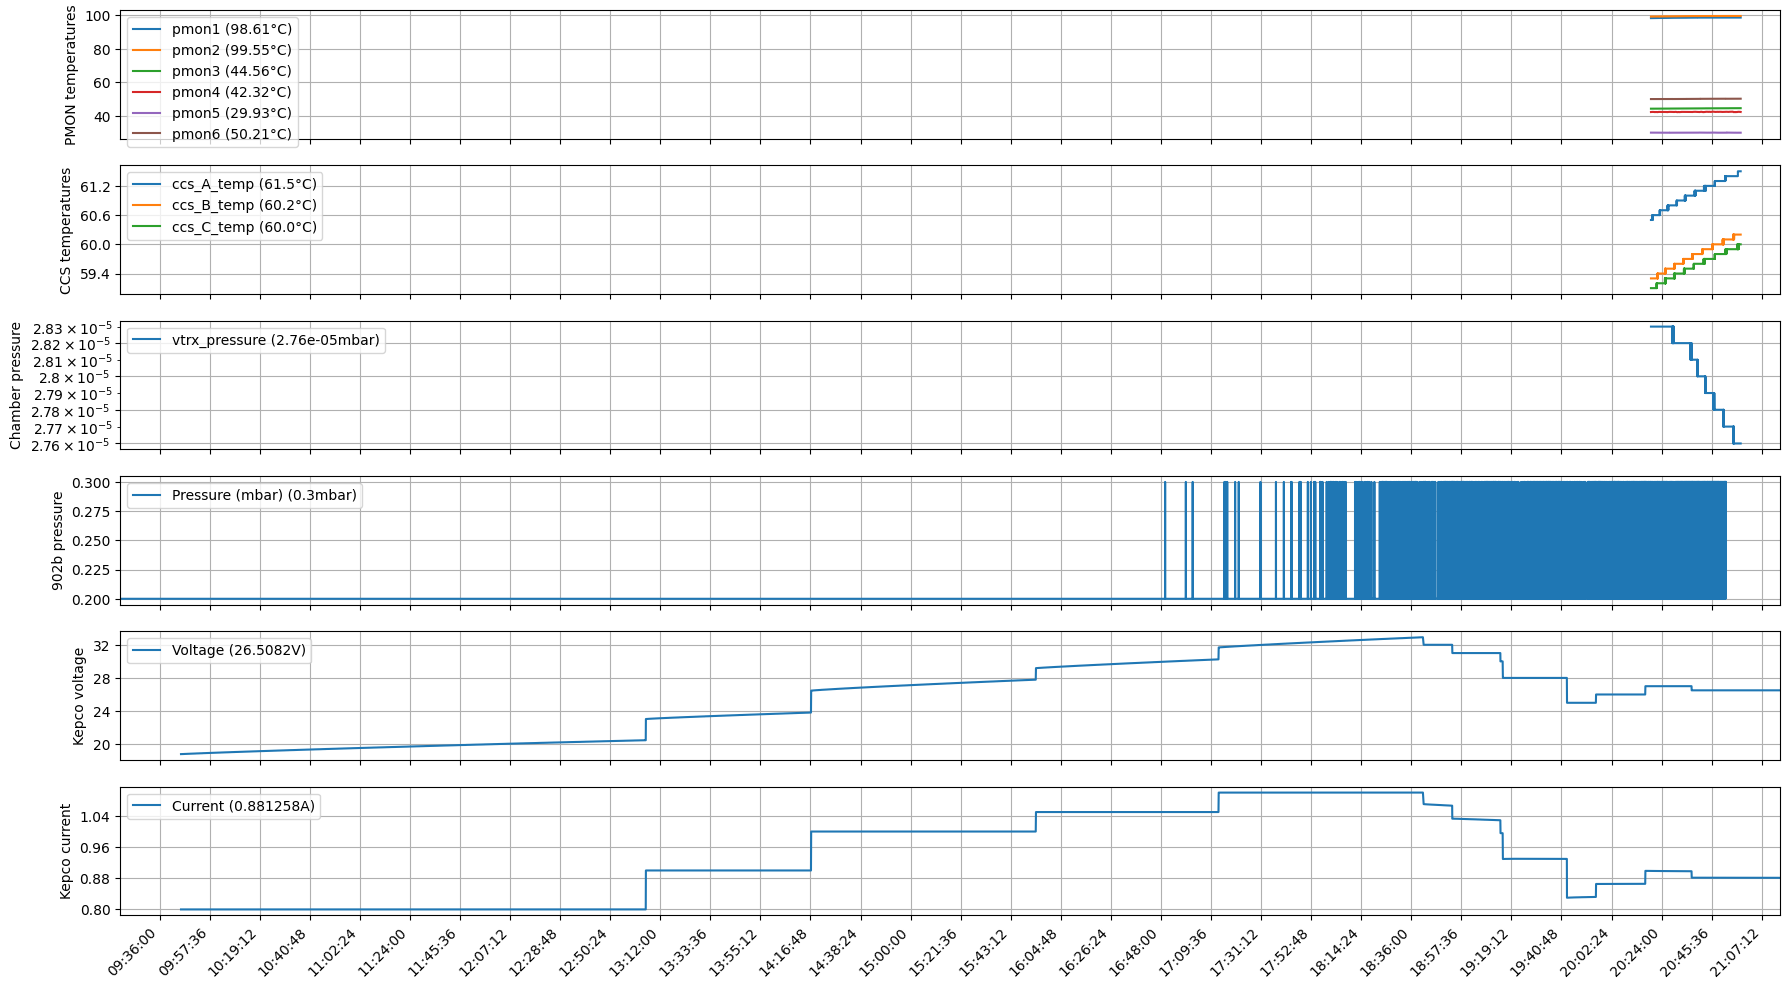

Generated graph at 2026-07-24 22:08:01.838936
Log parsing took: 0.11598589999994147
Graph object generation took: 0.016835800000990275
Graphing took: 1.2316376999988279
Total graphing time: 1.3645308000013756
Time since last loop: 1.4772747999995772


In [37]:
# Main cell where graph generation is called repeatedly. To use the above settings, you must restart this cell only
try:
    lastLoopTime = time.perf_counter()
    wmCacheInit()
    while True :
        lastLoopTime = mainLoop(lastLoopTime)
        clear_output(True)
except KeyboardInterrupt:
    clear_output()
    mainLoop(lastLoopTime)